# Module 4 — Stem Angle Extraction via PCA (v2: improved post-processing)
**AIDA 2158A Final Project | Mark Miller**

This notebook implements **Module 4** from the project specification:
> *"Stem angle extraction using PCA"*

**v2 improvements over v1 (outputs saved to `stem_angles_v2/`):**
- Prediction threshold lowered from 0.5 → 0.3: recovers uncertain stem pixels the model was discarding
- Connected component filtering: only the largest foreground blob is kept before PCA, removing noise blobs that were skewing angles by up to 30–40°

**Pipeline:**
1. Load the trained U-Net (`best_unet.pt`)
2. Run inference on the val images to get predicted peduncle masks
3. Post-process: threshold at 0.3, keep largest connected component
4. For each mask: extract white-pixel coordinates, fit PCA, extract principal axis angle
5. Overlay the principal axis line on the original image (grasp direction visualisation)
6. Plot the distribution of stem angles across the validation set
7. Print per-image results table

In [1]:
# Cell 1 — Imports and paths
%matplotlib inline
import sys, os, json, random
import numpy as np
import torch
import torch.nn as nn
import cv2
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 100
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.decomposition import PCA
from torchvision import transforms
from PIL import Image

BASE      = Path(r'c:\Users\markm\Documents\RDP\AIDA 2158\Final Project')
IMG_DIR   = BASE / 'peduncle_masks' / 'images'
MASK_DIR  = BASE / 'peduncle_masks' / 'masks'
WEIGHTS   = BASE / 'runs' / 'unet' / 'best_unet.pt'
OUT_DIR   = BASE / 'runs' / 'stem_angles_v2'
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
IMG_SIZE  = 256
VAL_SPLIT = 0.16   # must match module3 — last 16% of sorted filelist = val set

print(f'Device : {DEVICE}')
print(f'Weights: {WEIGHTS}')
print(f'Images : {len(list(IMG_DIR.glob("*.png")))} found')

Device : cuda
Weights: c:\Users\markm\Documents\RDP\AIDA 2158\Final Project\runs\unet\best_unet.pt
Images : 357 found


In [2]:
# Cell 2 — Rebuild U-Net architecture (exact copy from module3_unet_training.ipynb)

def double_conv(in_ch, out_ch):
    """Two 3x3 convolutions each followed by BatchNorm + ReLU."""
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoders  = nn.ModuleList()
        self.pool      = nn.MaxPool2d(2, 2)
        self.decoders  = nn.ModuleList()
        self.upsamples = nn.ModuleList()

        ch = in_channels
        for f in features:
            self.encoders.append(double_conv(ch, f))
            ch = f

        self.bottleneck = double_conv(features[-1], features[-1] * 2)

        for f in reversed(features):
            self.upsamples.append(nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2))
            self.decoders.append(double_conv(f * 2, f))

        self.final = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for enc in self.encoders:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skips = skips[::-1]
        for i, (up, dec) in enumerate(zip(self.upsamples, self.decoders)):
            x = up(x)
            skip = skips[i]
            if x.shape != skip.shape:
                x = nn.functional.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = dec(x)
        return torch.sigmoid(self.final(x))

model = UNet().to(DEVICE)
model.load_state_dict(torch.load(WEIGHTS, map_location=DEVICE))
model.eval()
print('U-Net loaded — parameters:', sum(p.numel() for p in model.parameters()))

U-Net loaded — parameters: 31037633


In [3]:
# Cell 3 — Reconstruct the same val split used in module3

all_imgs  = sorted(IMG_DIR.glob('*.png'))
n_val     = int(len(all_imgs) * VAL_SPLIT)
val_imgs  = all_imgs[-n_val:]   # last N = val set (matches module3 split)

print(f'Total images : {len(all_imgs)}')
print(f'Val images   : {len(val_imgs)}')
print(f'Sample names : {[p.name for p in val_imgs[:3]]}')

Total images : 357
Val images   : 57
Sample names : ['markm_109_jpg.rf.tCnpuxZjD6Ec3HOE93Gq.png', 'markm_10_jpg.rf.2JpPw8gMIeTfpR7OfDTf.png', 'markm_10_jpg.rf.dWBDT2LItraJylnFgQ6D.png']


In [4]:
# Cell 4 — Run U-Net inference + PCA on each val image

tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

THRESHOLD = 0.3   # v2: lowered from 0.5 — recovers uncertain stem pixels

def predict_mask(img_path):
    """Return binarised 256x256 predicted mask (numpy uint8), largest component only."""
    img = Image.open(img_path).convert('RGB')
    tensor = tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        prob = model(tensor)  # sigmoid already applied inside model.forward()
    prob = prob.squeeze().cpu().numpy()
    mask = (prob > THRESHOLD).astype(np.uint8) * 255
    # v2: keep only the largest connected component — removes isolated noise blobs
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = np.where(labels == largest, 255, 0).astype(np.uint8)
    return mask

def pca_angle(mask):
    """
    Given a binary mask (255=foreground), extract foreground pixel coords,
    fit 2-component PCA, return principal axis angle in degrees.
    Returns None if fewer than 10 foreground pixels.
    """
    ys, xs = np.where(mask > 127)
    if len(xs) < 10:
        return None
    coords = np.column_stack([xs, ys]).astype(float)
    pca = PCA(n_components=2)
    pca.fit(coords)
    # Principal component direction vector
    dx, dy = pca.components_[0]
    # Angle from horizontal, in degrees (-90 to +90)
    angle = np.degrees(np.arctan2(dy, dx))
    return angle

results = []   # list of dicts
for img_path in val_imgs:
    mask_pred = predict_mask(img_path)
    angle     = pca_angle(mask_pred)
    gt_path   = MASK_DIR / img_path.name
    results.append({
        'name'     : img_path.name,
        'img_path' : img_path,
        'gt_path'  : gt_path,
        'mask_pred': mask_pred,
        'angle'    : angle,
    })

valid    = [r for r in results if r['angle'] is not None]
no_pred  = [r for r in results if r['angle'] is None]
print(f'Val images processed : {len(results)}')
print(f'With valid mask      : {len(valid)}')
print(f'No foreground found  : {len(no_pred)}')
if valid:
    angles = [r['angle'] for r in valid]
    print(f'Mean angle  : {np.mean(angles):.1f} deg')
    print(f'Std dev     : {np.std(angles):.1f} deg')
    print(f'Min / Max   : {np.min(angles):.1f} / {np.max(angles):.1f} deg')

Val images processed : 57
With valid mask      : 50
No foreground found  : 7
Mean angle  : 59.2 deg
Std dev     : 44.4 deg
Min / Max   : -43.2 / 132.6 deg


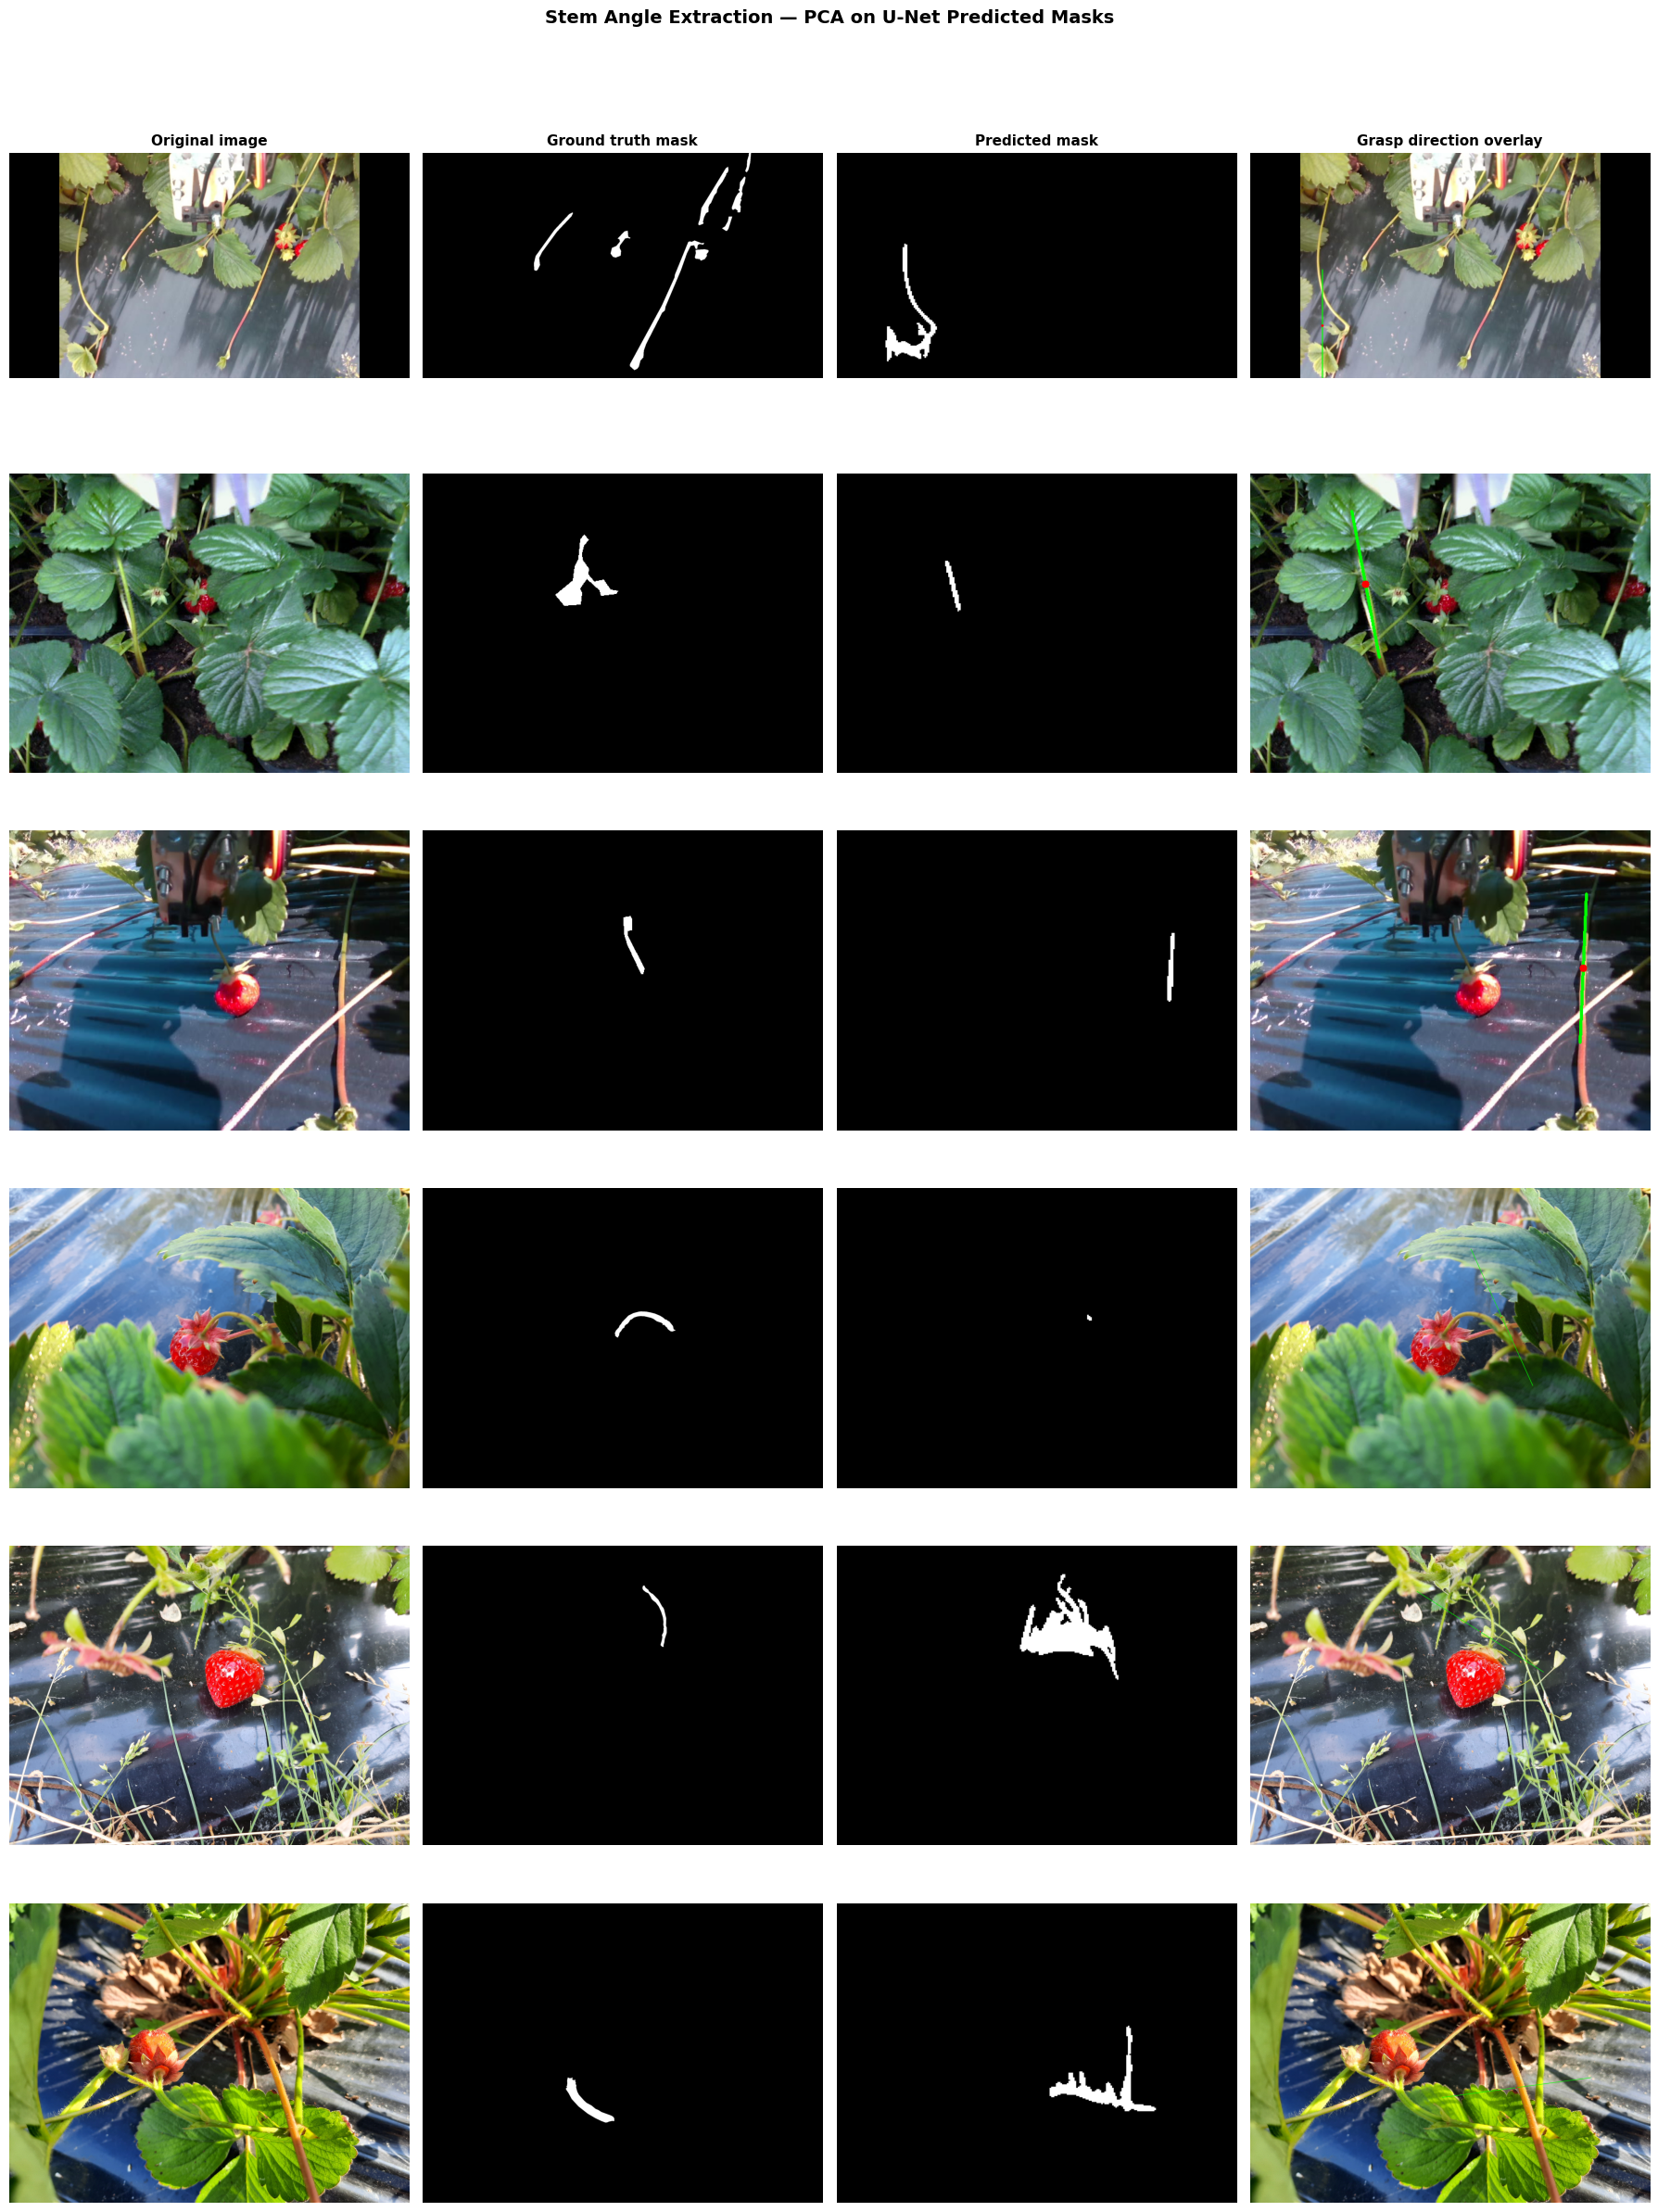

Saved → c:\Users\markm\Documents\RDP\AIDA 2158\Final Project\runs\stem_angles_v2\stem_angle_examples.png


In [5]:
# Cell 5 — Visualise: 6 examples with principal axis overlay

def draw_axis(img_bgr, mask_256, angle_deg, orig_h, orig_w):
    """
    Draw the PCA principal axis line on the full-resolution image.
    mask_256 is the 256x256 predicted mask — we scale the centroid back.
    """
    # Find centroid in 256x256 space, scale to original image size
    ys, xs = np.where(mask_256 > 127)
    if len(xs) == 0:
        return img_bgr
    cx = int(np.mean(xs) / IMG_SIZE * orig_w)
    cy = int(np.mean(ys) / IMG_SIZE * orig_h)
    length = min(orig_w, orig_h) // 4
    rad = np.radians(angle_deg)
    dx  = int(np.cos(rad) * length)
    dy  = int(np.sin(rad) * length)
    out = img_bgr.copy()
    cv2.line(out, (cx - dx, cy - dy), (cx + dx, cy + dy), (0, 255, 0), 3)
    cv2.circle(out, (cx, cy), 6, (0, 0, 255), -1)
    return out

sample = random.sample(valid, min(6, len(valid)))

fig, axes = plt.subplots(len(sample), 4, figsize=(18, 4 * len(sample)))
if len(sample) == 1:
    axes = [axes]

col_labels = ['Original image', 'Ground truth mask', 'Predicted mask', 'Grasp direction overlay']
for ax, label in zip(axes[0], col_labels):
    ax.set_title(label, fontsize=11, fontweight='bold')

for row, r in enumerate(sample):
    img_bgr  = cv2.imread(str(r['img_path']))
    orig_h, orig_w = img_bgr.shape[:2]
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    gt_mask  = cv2.imread(str(r['gt_path']), cv2.IMREAD_GRAYSCALE) if r['gt_path'].exists() else np.zeros((orig_h, orig_w), dtype=np.uint8)

    overlay  = draw_axis(img_bgr, r['mask_pred'], r['angle'], orig_h, orig_w)
    overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    # Resize predicted mask to original dimensions for display
    pred_disp = cv2.resize(r['mask_pred'], (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

    for ax in axes[row]:
        ax.axis('off')

    axes[row][0].imshow(img_rgb)
    axes[row][0].set_xlabel(r['name'][:40], fontsize=7)
    axes[row][1].imshow(gt_mask, cmap='gray')
    axes[row][2].imshow(pred_disp, cmap='gray')
    axes[row][3].imshow(overlay_rgb)
    axes[row][3].set_xlabel(f'Angle: {r["angle"]:.1f}°', fontsize=9, color='green')

plt.suptitle('Stem Angle Extraction — PCA on U-Net Predicted Masks', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
out_path = OUT_DIR / 'stem_angle_examples.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

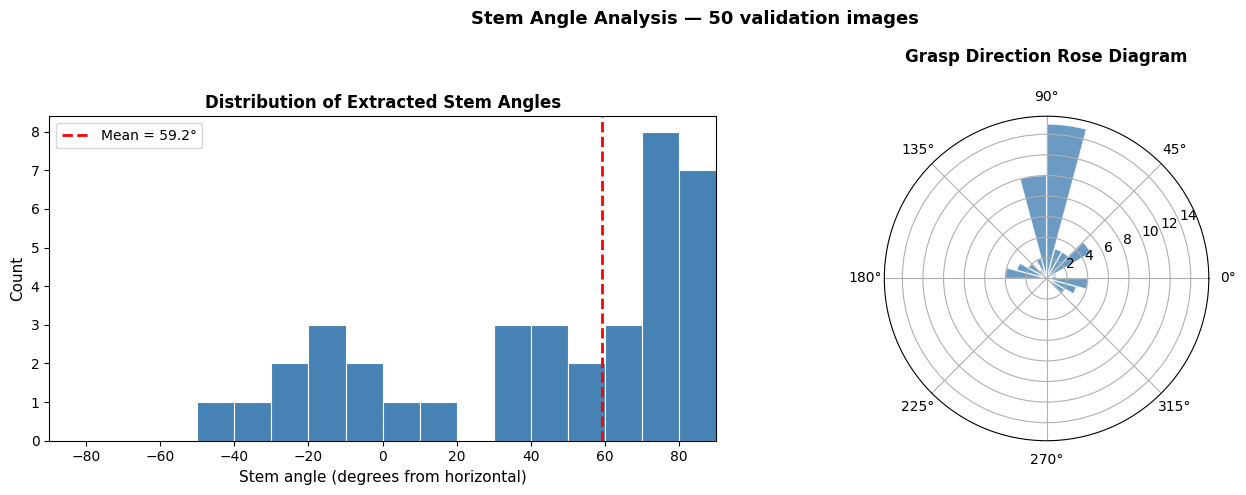

Saved → c:\Users\markm\Documents\RDP\AIDA 2158\Final Project\runs\stem_angles_v2\stem_angle_distribution.png


In [6]:
# Cell 6 — Angle distribution histogram

angles = [r['angle'] for r in valid]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(angles, bins=18, range=(-90, 90), color='steelblue', edgecolor='white', linewidth=0.8)
axes[0].axvline(np.mean(angles), color='red', linewidth=2, linestyle='--', label=f'Mean = {np.mean(angles):.1f}°')
axes[0].set_xlabel('Stem angle (degrees from horizontal)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Distribution of Extracted Stem Angles', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].set_xlim(-90, 90)

# Polar / rose diagram for grasp direction
ax_polar = fig.add_subplot(122, projection='polar')
fig.delaxes(axes[1])
angle_rad = np.radians(angles)
# Mirror angles (stem direction is axisymmetric — 30° and -150° are same grasp)
both = np.concatenate([angle_rad, angle_rad + np.pi])
n_bins = 24
bins   = np.linspace(-np.pi, np.pi, n_bins + 1)
counts, _ = np.histogram(both, bins=bins)
theta  = (bins[:-1] + bins[1:]) / 2
width  = 2 * np.pi / n_bins
ax_polar.bar(theta, counts, width=width, color='steelblue', edgecolor='white', alpha=0.8)
ax_polar.set_title('Grasp Direction Rose Diagram', fontsize=12, fontweight='bold', pad=20)
ax_polar.set_theta_zero_location('E')

plt.suptitle(f'Stem Angle Analysis — {len(valid)} validation images', fontsize=13, fontweight='bold')
plt.tight_layout()
out_path2 = OUT_DIR / 'stem_angle_distribution.png'
plt.savefig(out_path2, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path2}')

In [7]:
# Cell 7 — Per-image results table

print(f'{"Image":<55} {"Angle (deg)":>12}')
print('-' * 70)
for r in results:
    angle_str = f'{r["angle"]:+.1f}' if r['angle'] is not None else '  no mask'
    print(f'{r["name"][:54]:<55} {angle_str:>12}')

print()
if valid:
    angles = [r['angle'] for r in valid]
    print('=== Summary ===')
    print(f'Images with valid mask : {len(valid)} / {len(results)}')
    print(f'Mean angle             : {np.mean(angles):+.1f} deg')
    print(f'Std deviation          : {np.std(angles):.1f} deg')
    print(f'Min / Max              : {np.min(angles):+.1f} / {np.max(angles):+.1f} deg')
    print()
    print('Interpretation:')
    print('  Angle = 0°  → stem points horizontally (gripper approaches from side)')
    print('  Angle = 90° → stem points vertically upward (gripper approaches from below)')
    print('  The principal axis defines the optimal gripper alignment for the robotic arm.')

Image                                                    Angle (deg)
----------------------------------------------------------------------
markm_109_jpg.rf.tCnpuxZjD6Ec3HOE93Gq.png                      +85.5
markm_10_jpg.rf.2JpPw8gMIeTfpR7OfDTf.png                     no mask
markm_10_jpg.rf.dWBDT2LItraJylnFgQ6D.png                       -24.7
markm_10_jpg.rf.fyZmFfWsBzNYNowRdiTh.png                       +44.6
markm_110_jpg.rf.R94QlaGkbKLKfewGxwsP.png                      +37.3
markm_110_jpg.rf.TVCZJC1OB2NvvQUPq4sk.png                    no mask
markm_111_jpg.rf.3wbhBuhiVGTUMr3x18Xt.png                      +97.8
markm_111_jpg.rf.K3aUPDtGfgqZed5335hh.png                      +85.6
markm_112_jpg.rf.LUaQ4JGl0LBEo0Bdpi1q.png                     +103.9
markm_112_jpg.rf.oNNnWx7MP0ELwlZ3qiCO.png                     +132.6
markm_113_jpg.rf.X9PYKIJCB1xKq25CsXn2.png                       -7.6
markm_114_jpg.rf.CjbUsh22wF9rC8XDhUm3.png                     +101.2
markm_114_jpg.rf.fWa6irUEb5tDQjK

In [8]:
# Cell 8 — Save angle data to JSON for Phase 7 packaging

out_json = OUT_DIR / 'stem_angles.json'
export = [
    {'image': r['name'], 'angle_deg': round(r['angle'], 2) if r['angle'] is not None else None}
    for r in results
]
with open(out_json, 'w') as f:
    json.dump(export, f, indent=2)

print(f'Angle data saved → {out_json}')
print(f'Files in {OUT_DIR}:')
for p in sorted(OUT_DIR.iterdir()):
    print(f'  {p.name}')

Angle data saved → c:\Users\markm\Documents\RDP\AIDA 2158\Final Project\runs\stem_angles_v2\stem_angles.json
Files in c:\Users\markm\Documents\RDP\AIDA 2158\Final Project\runs\stem_angles_v2:
  stem_angle_distribution.png
  stem_angle_examples.png
  stem_angles.json
